# Statistics Advance-1 Assignment
### Data Science Masters - PW Skills

## Q1. What is the Probability Density Function?

A **Probability Density Function (PDF)** describes the likelihood of a continuous random variable taking a specific value.

Key points:
- It is used for **continuous** random variables (not discrete).
- The PDF itself does NOT give probability at a single point — instead, the **area under the curve** between two points gives the probability.
- Total area under the PDF curve = 1.
- Mathematically: P(a ≤ X ≤ b) = ∫ f(x) dx from a to b

Example: The bell-shaped curve of a Normal Distribution is a classic PDF.

## Q2. What are the types of Probability Distribution?

Probability distributions are broadly classified into two types:

**1. Discrete Distributions** (for countable outcomes):
- Binomial Distribution
- Poisson Distribution
- Bernoulli Distribution
- Geometric Distribution
- Hypergeometric Distribution

**2. Continuous Distributions** (for uncountable/continuous outcomes):
- Normal (Gaussian) Distribution
- Uniform Distribution
- Exponential Distribution
- Beta Distribution
- Chi-Square Distribution
- t-Distribution
- F-Distribution

## Q3. Python function to calculate PDF of Normal Distribution

In [1]:
import numpy as np

def normal_pdf(x, mean, std):
    """
    Calculate the PDF of a normal distribution at a given point x.
    Parameters:
        x    : the point at which PDF is calculated
        mean : mean of the distribution
        std  : standard deviation of the distribution
    Returns:
        PDF value at x
    """
    coefficient = 1 / (std * np.sqrt(2 * np.pi))
    exponent = -0.5 * ((x - mean) / std) ** 2
    return coefficient * np.exp(exponent)

# Example usage
mean = 0
std  = 1
x    = 0

result = normal_pdf(x, mean, std)
print(f"PDF of Normal(mean={mean}, std={std}) at x={x}: {result:.6f}")

# Verify with scipy
from scipy.stats import norm
print(f"scipy verification: {norm.pdf(x, mean, std):.6f}")

PDF of Normal(mean=0, std=1) at x=0: 0.398942


scipy verification: 0.398942


## Q4. Properties of Binomial Distribution + Two Examples

**Properties of Binomial Distribution:**

1. Fixed number of trials (n).
2. Each trial has only two outcomes: **Success** or **Failure**.
3. Probability of success (p) remains **constant** across all trials.
4. All trials are **independent** of each other.
5. Mean = n × p
6. Variance = n × p × (1 - p)
7. PMF: P(X = k) = C(n,k) × p^k × (1-p)^(n-k)

**Two Real-World Examples:**

1. **Coin Tossing**: Tossing a fair coin 10 times and counting the number of heads. Each toss is independent, has 2 outcomes (H/T), and p = 0.5 is fixed.

2. **Quality Control**: A factory produces 100 items. Each item is either defective or non-defective with a defect probability of 0.05. Counting the number of defective items follows a Binomial distribution.

## Q5. Random sample from Binomial distribution (n=1000, p=0.4) + Histogram

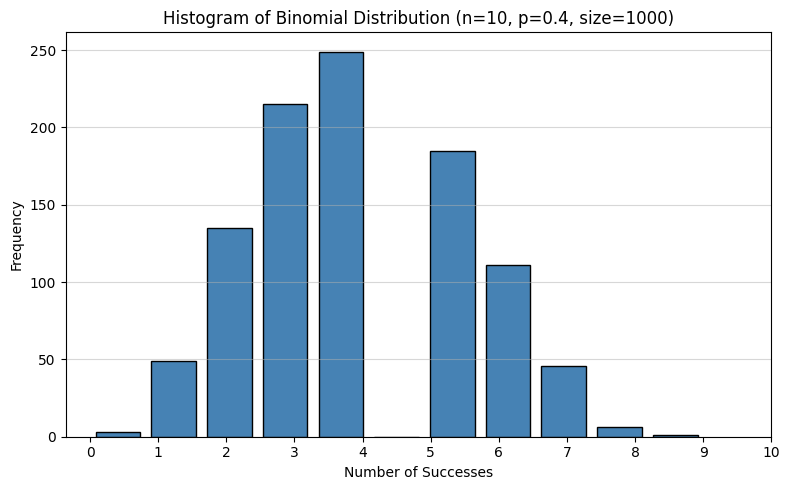

Sample Mean    : 3.9300
Sample Variance: 2.4031
Theoretical Mean    : 4.0
Theoretical Variance: 2.4


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate 1000 samples from Binomial(n=10, p=0.4)
sample = np.random.binomial(n=10, p=0.4, size=1000)

plt.figure(figsize=(8, 5))
plt.hist(sample, bins=11, color='steelblue', edgecolor='black', rwidth=0.8)
plt.title('Histogram of Binomial Distribution (n=10, p=0.4, size=1000)')
plt.xlabel('Number of Successes')
plt.ylabel('Frequency')
plt.xticks(range(11))
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Sample Mean    : {sample.mean():.4f}")
print(f"Sample Variance: {sample.var():.4f}")
print(f"Theoretical Mean    : {10 * 0.4}")
print(f"Theoretical Variance: {10 * 0.4 * 0.6}")

## Q6. Python function to calculate CDF of Poisson Distribution

In [3]:
import math

def poisson_cdf(k, mean):
    """
    Calculate the CDF of Poisson distribution at point k.
    CDF = P(X <= k) = sum of PMF from 0 to k
    Parameters:
        k    : upper limit (integer)
        mean : lambda (average rate)
    Returns:
        Cumulative probability P(X <= k)
    """
    cdf = 0
    for i in range(k + 1):
        cdf += (math.exp(-mean) * mean**i) / math.factorial(i)
    return cdf

# Example usage
lam = 3   # mean
k   = 4   # point

result = poisson_cdf(k, lam)
print(f"Poisson CDF (mean={lam}) at k={k}: {result:.6f}")

# Verify with scipy
from scipy.stats import poisson
print(f"scipy verification              : {poisson.cdf(k, lam):.6f}")

Poisson CDF (mean=3) at k=4: 0.815263
scipy verification              : 0.815263


## Q7. How is Binomial Distribution different from Poisson Distribution?

| Feature | Binomial Distribution | Poisson Distribution |
|---|---|---|
| **Number of trials** | Fixed (n) | Infinite / Not fixed |
| **Outcomes per trial** | 2 (Success/Failure) | Counts of events |
| **Probability (p)** | Fixed and known | Very small (rare events) |
| **Parameters** | n and p | λ (lambda = mean) |
| **Mean** | n × p | λ |
| **Variance** | n × p × (1-p) | λ |
| **Use case** | Coin flips, pass/fail tests | Calls per hour, accidents per day |
| **Relation** | When n→∞ and p→0, Binomial → Poisson (with λ = np) | Special case of Binomial |

**Key takeaway**: Poisson is used when events are **rare**, trials are **large**, and p is **very small**.

## Q8. Random sample from Poisson distribution (mean=5, size=1000) — Mean & Variance

In [4]:
import numpy as np

np.random.seed(42)

# Generate 1000 samples from Poisson(lambda=5)
sample_poisson = np.random.poisson(lam=5, size=1000)

sample_mean = sample_poisson.mean()
sample_var  = sample_poisson.var()

print(f"Sample Mean    : {sample_mean:.4f}")
print(f"Sample Variance: {sample_var:.4f}")
print(f"\nTheoretical Mean (λ)    : 5")
print(f"Theoretical Variance (λ): 5")
print("\nObservation: Sample mean and variance both ≈ 5 (= λ), confirming Poisson property.")

Sample Mean    : 4.9850
Sample Variance: 4.9968

Theoretical Mean (λ)    : 5
Theoretical Variance (λ): 5

Observation: Sample mean and variance both ≈ 5 (= λ), confirming Poisson property.


## Q9. How are Mean and Variance related in Binomial and Poisson distributions?

**Binomial Distribution:**
- Mean     = n × p
- Variance = n × p × (1 - p) = Mean × (1 - p)
- Since (1-p) < 1, **Variance < Mean** always in Binomial.
- The variance depends on both n and p.

**Poisson Distribution:**
- Mean     = λ
- Variance = λ
- **Mean = Variance** — this is the defining property of Poisson distribution.
- Both are controlled by the single parameter λ.

**Connection:**
When n is very large and p is very small in Binomial, n×p → λ, and (1-p) → 1, so Variance → Mean. This is exactly the Poisson property — Poisson is essentially the limiting case of Binomial.

## Q10. In Normal Distribution, where does the least frequent data appear?

In a Normal Distribution, the **least frequent data** appears at the **tails** — i.e., the extreme ends farthest from the mean (both left and right).

- The **mean** is the center of the bell curve — highest frequency (most common).
- As you move away from the mean (toward ±∞), frequency drops sharply.
- Data beyond **3 standard deviations** (μ ± 3σ) is extremely rare — covers only ~0.3% of data.

So: **Least frequent data → extreme left and extreme right tails of the distribution.**

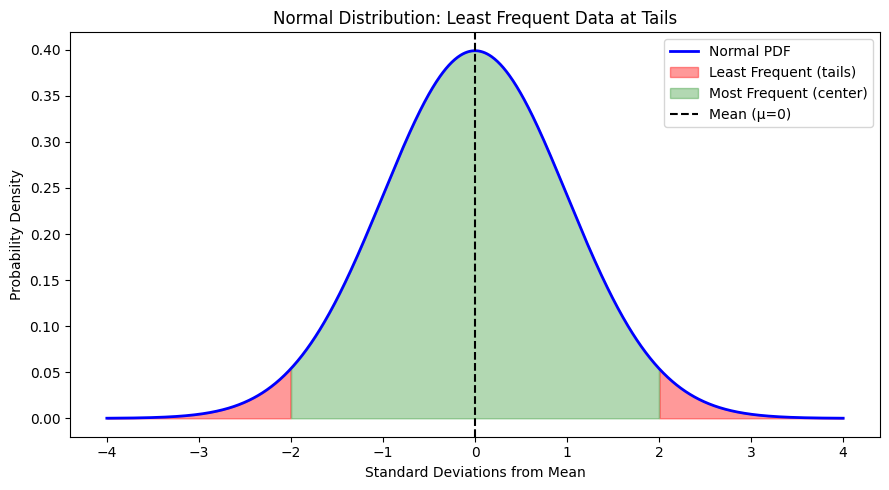

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)

plt.figure(figsize=(9, 5))
plt.plot(x, y, 'b-', linewidth=2, label='Normal PDF')

# Shade tails (least frequent region)
plt.fill_between(x, y, where=(x < -2), color='red', alpha=0.4, label='Least Frequent (tails)')
plt.fill_between(x, y, where=(x > 2),  color='red', alpha=0.4)

# Shade center (most frequent region)
plt.fill_between(x, y, where=((x >= -2) & (x <= 2)), color='green', alpha=0.3, label='Most Frequent (center)')

plt.axvline(0, color='black', linestyle='--', label='Mean (μ=0)')
plt.title('Normal Distribution: Least Frequent Data at Tails')
plt.xlabel('Standard Deviations from Mean')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()